# Face Recognition Pipeline

Stage 3 of the [computer-vision path](../README.md). It combines the three previous stages: detection ([2-yolo](../2-yolo/object_detection_and_yolo.ipynb)), embeddings ([vectors_and_embeddings](vectors_and_embeddings.ipynb)) and vector search ([chromadb_intro](chromadb_intro.ipynb)).

## Pipeline Overview

Everything in this module converges here. The face recognition pipeline chains together four separate concepts:

1. **Detection** (YOLO) — locate where a person appears in an image.
2. **Embedding** (CLIP) — convert the detected face crop into a 512-D vector.
3. **Storage** (ChromaDB) — persist that vector alongside identity metadata.
4. **Verification** — given a new face image, find the closest stored embedding and decide whether the similarity is high enough to confirm identity.

Deployed face recognition systems, from door access control to mobile unlock, share this structure. Two of their components are stronger than ours, though: a **face** detector instead of a person detector, and an embedding model trained to recognise **identities** (ArcFace, FaceNet, SFace) instead of CLIP. We use YOLO and CLIP because the previous notebooks introduced them. What transfers to real systems is the structure, not these two model choices.

The full pipeline has five steps:

| Step | What happens | Key tool |
|------|-------------|---------|
| **1. Capture** | Get a photo of a face (webcam or file) | OpenCV `VideoCapture` |
| **2. Detect** | Locate the person inside the image, crop it | YOLO26 `yolo26n.pt` |
| **3. Embed** | Convert the crop to a 512-D vector | CLIP `clip-ViT-B-32` |
| **4. Store** | Save the vector + metadata to a DB | ChromaDB |
| **5. Verify** | Query the DB with a new face; decide match/no-match | cosine similarity |

**Enrollment** = steps 1-4 (done once, when registering a person).
**Verification** = steps 1-3 then 5 (done at each access attempt).

## Capture a Face

In a production system, frames come from a live webcam.
Here we load static photos from the `resources/images/` folder so the notebook runs without a camera,
and then show the equivalent webcam code with detailed annotations.

In [ ]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

IMG_DIR = Path('../resources/images')
names = ['scene1', 'scene2', 'scene3']

face_images = {name: cv2.imread(str(IMG_DIR / f'{name}.jpg')) for name in names}

for name, img in face_images.items():
    assert img is not None, f'Could not load {IMG_DIR / name}.jpg'
    print(f'{name}: {img.shape}')

scene1: (427, 640, 3)
scene2: (959, 640, 3)
scene3: (960, 640, 3)


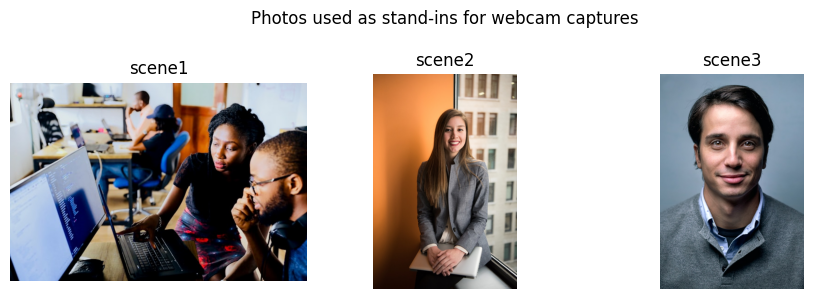

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, name in zip(axes, names):
    ax.imshow(cv2.cvtColor(face_images[name], cv2.COLOR_BGR2RGB))
    ax.set_title(name)
    ax.axis('off')
plt.suptitle('Photos used as stand-ins for webcam captures')
plt.tight_layout()
plt.show()

### Webcam Capture Code

> **Note:** The cell below is shown for reference — it requires a physical webcam and
> a GUI display. Do not run it in a headless/cloud environment.

Its two quality checks (brightness and sharpness) become `check_image_quality()` in the [application](../4-face-auth-app/quality_guard.py).

In [ ]:
# ⚠️ REFERENCE ONLY — requires webcam + GUI display

def capture_faces_from_webcam(n_captures: int = 5) -> list[np.ndarray]:
    captures = []
    cap = cv2.VideoCapture(0)  # 0 = first camera

    while len(captures) < n_captures:
        ret, frame = cap.read()
        if not ret:
            break

        # Quality check 1: brightness
        # A mean pixel value outside 50–200 means too dark or overexposed.
        brightness = frame.mean()
        if not (50 < brightness < 200):
            cv2.putText(frame, 'Bad lighting!', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            cv2.imshow('Capture', frame)
            cv2.waitKey(100)
            continue

        # Quality check 2: blur (Laplacian variance)
        # A blurry frame has low variation in second derivative.
        # Threshold of 100 is a typical rule of thumb.
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
        if blur_score < 100:
            cv2.putText(frame, 'Too blurry!', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            cv2.imshow('Capture', frame)
            cv2.waitKey(100)
            continue

        captures.append(frame.copy())
        cv2.putText(frame, f'Captured {len(captures)}/{n_captures}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.imshow('Capture', frame)
        cv2.waitKey(500)  # brief pause between captures

    # Releases the camera so other applications can use it.
    cap.release()
    # Closes all GUI windows created by cv2.imshow().
    cv2.destroyAllWindows()
    return captures

# _ = capture_faces_from_webcam()

## Detect the Person with YOLO

The general YOLO model (`yolo26n.pt`, trained on COCO) detects **people** as class 0, not faces: the box covers the whole visible body.
We take the highest-confidence person box and crop it.

A real deployment would use a face detector, which returns a tight box around the face and often landmarks to align it: OpenCV's `cv2.FaceDetectorYN`, or a community YOLO model fine-tuned on faces (weights such as `yolov8n-face` are not official Ultralytics releases).

In [ ]:
from ultralytics import YOLO

# Load the nano model (smallest/fastest).
# Downloads ~5 MB on first run into resources/models/ (gitignored), shared with 2-yolo.
MODELS_DIR = Path('../resources/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
detector = YOLO(MODELS_DIR / 'yolo26n.pt')
print('Detector loaded')

Detector loaded


In [ ]:
def detect_and_crop_person(img: np.ndarray, padding: int = 20) -> np.ndarray:
    h, w = img.shape[:2]

    # Run inference; suppress console output with verbose=False.
    results = detector(img, verbose=False)
    boxes = results[0].boxes

    # Filter to class 0 (person), keep the highest-confidence detection.
    # On photos with no detected person, fall back to the whole image.
    best_box = None
    best_conf = 0
    for box in boxes:
        if int(box.cls[0]) == 0 and float(box.conf[0]) > best_conf:
            best_conf = float(box.conf[0])
            best_box = box.xyxy[0].cpu().numpy().astype(int)

    if best_box is None:
        # No person detected — use the whole image instead.
        # In a production system you would reject this frame instead.
        return img

    x1, y1, x2, y2 = best_box
    # Add padding around the box, clamped to image boundaries.
    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(w, x2 + padding)
    y2 = min(h, y2 + padding)
    return img[y1:y2, x1:x2]


person_crops = {name: detect_and_crop_person(face_images[name]) for name in names}
for name, crop in person_crops.items():
    print(f'{name}: crop shape = {crop.shape}')

scene1: crop shape = (403, 346, 3)
scene2: crop shape = (826, 377, 3)
scene3: crop shape = (931, 640, 3)


The `padding` parameter expands the bounding box by `padding` pixels on all sides before cropping, so that a box that is slightly too tight does not cut off the head or the edges of the person.

The box is clamped to image boundaries, so padding never reads outside the image.

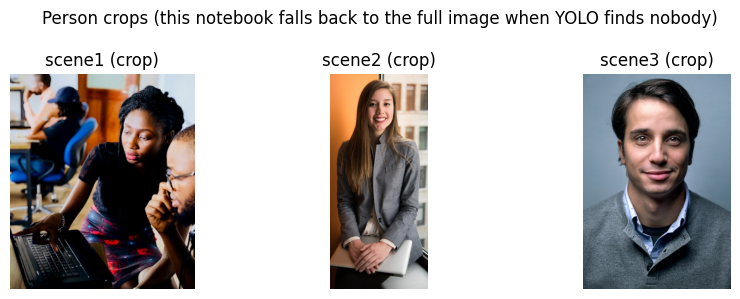

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, name in zip(axes, names):
    ax.imshow(cv2.cvtColor(person_crops[name], cv2.COLOR_BGR2RGB))
    ax.set_title(f'{name} (crop)')
    ax.axis('off')
plt.suptitle('Person crops (this notebook falls back to the full image when YOLO finds nobody)')
plt.tight_layout()
plt.show()

## Extract an Embedding with CLIP

We pass each person crop through the CLIP image encoder to get a 512-D vector.

Two implementation details matter here:

- **L2 normalisation before storage**: CLIP's outputs are not unit length, so we scale each vector to length 1. The collection below ranks neighbours by cosine distance, which ignores length, so this step is not needed for correctness *here*. It makes the stored vectors safe for any metric (for unit vectors, inner product and Euclidean distance rank neighbours exactly as cosine does), and it makes a plain dot product equal to cosine similarity.

- **BGR → RGB conversion**: OpenCV loads images as BGR; CLIP (via PIL) expects RGB. Skipping this step swaps the red and blue channels, so the embedding silently describes a differently coloured image.

In [ ]:
from sentence_transformers import SentenceTransformer

clip_model = SentenceTransformer('clip-ViT-B-32')

/home/avidaldo/TRABAJO/wip-clase/PIA-SAA/example_repos/computer-vision/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 23046.58it/s]


CLIPModel LOAD REPORT from: /home/avidaldo/.cache/huggingface/hub/models--sentence-transformers--clip-ViT-B-32/snapshots/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [ ]:
def embed_face(bgr_crop: np.ndarray) -> np.ndarray:
    # Convert BGR (OpenCV default) → RGB (PIL/CLIP default).
    rgb = cv2.cvtColor(bgr_crop, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(rgb)
    emb = clip_model.encode(pil_img)   # numpy float32 array, shape (512,)
    # L2-normalise so that dot product == cosine similarity.
    emb = emb / np.linalg.norm(emb)
    return emb

for name in names:
    emb = embed_face(person_crops[name])
    print(f'{name}: shape={emb.shape}  norm={np.linalg.norm(emb):.6f}')

scene1: shape=(512,)  norm=1.000000
scene2: shape=(512,)  norm=1.000000
scene3: shape=(512,)  norm=1.000000


## Store Embeddings in ChromaDB

We create a persistent ChromaDB collection and insert one embedding per person.
The metadata includes the person's name and the enrollment timestamp.

In [ ]:
import chromadb
import datetime
from pathlib import Path

# PersistentClient saves data to disk — survives notebook restarts.
db_path = Path('../artifacts/face_db')
db_path.mkdir(parents=True, exist_ok=True)
db_client = chromadb.PersistentClient(path=str(db_path))

# Delete the collection if it already exists (clean slate for this demo).
try:
    db_client.delete_collection('enrolled_faces')
    print('Old collection deleted')
except Exception:
    pass

# Cosine distance: compare directions, as CLIP was trained to.
face_collection = db_client.create_collection(
    name='enrolled_faces',
    configuration={'hnsw': {'space': 'cosine'}},
)
print('Collection ready')

Collection ready


In [ ]:
# Enroll the three people
for name in names:
    emb = embed_face(person_crops[name])
    face_collection.add(
        ids        = [f'{name}_enroll_001'],
        embeddings = [emb.tolist()],
        metadatas  = [{'name': name,
                        'enrolled_at': datetime.datetime.now().isoformat(),
                        'source': 'static_image_demo'}]
    )

print(f'Enrolled {face_collection.count()} face(s) in ChromaDB')

Enrolled 3 face(s) in ChromaDB


## Verify Identity (Similarity Search)

At verification time, the person presents a new photo.
We embed it and query the database for the closest stored embedding.

**Decision rule**: if the top match has cosine_similarity ≥ threshold → identity confirmed.

Tuning the threshold:
- Too high (e.g. 0.99) → many false rejections: genuine users are locked out (secure but inconvenient).
- Too low (e.g. 0.5) → false acceptances: strangers who merely look similar — or, with CLIP, photos that are merely *composed* similarly — get in.
- The `0.85` below is only a starting value. The right threshold comes from measurements: the similarities of genuine pairs (same person, different photo) against impostor pairs (different people). The [application's README](../4-face-auth-app/README.md) reports such measurements for these images.

In [ ]:
VERIFICATION_THRESHOLD = 0.85

def verify_identity(query_crop: np.ndarray, claimed_name: str | None = None) -> dict:
    query_emb = embed_face(query_crop)

    # Optionally narrow the search to the claimed identity (1:1 verification).
    where_clause = {'name': claimed_name} if claimed_name else None

    results = face_collection.query(
        query_embeddings = [query_emb.tolist()],
        n_results = 3,
        where = where_clause,
        include = ['metadatas', 'distances'],
    )

    top_id   = results['ids'][0][0]
    top_dist = results['distances'][0][0]
    top_meta = results['metadatas'][0][0]
    # ChromaDB returns cosine DISTANCE (0 = identical, 2 = opposite).
    # Convert to similarity: similarity = 1 − distance.
    similarity = 1.0 - top_dist

    return {
        'verified': similarity >= VERIFICATION_THRESHOLD,
        'similarity': similarity,
        'matched_id': top_id,
        'matched_name': top_meta['name'],
        'all_results': list(zip(results['ids'][0], [1-d for d in results['distances'][0]]))
    }

## Enrollment + Verification Demo

First we query each enrolled image against the database. This is **not** a real test: the query is the very image we enrolled, so the similarity is 1.000 by construction. A real test needs a *different* photo of the same person, which these sample images do not include.

Then we try people who were never enrolled (`face1`–`face3`). They must be rejected, and their similarities show how close CLIP places strangers to the enrolled people. Finally, a 1:1 check: `scene1`'s photo claiming to be `scene2`.

In [ ]:
print('=== Enrolled images queried again (1.000 by construction) ===')
for name in names:
    result = verify_identity(person_crops[name])
    status = '✓ VERIFIED' if result['verified'] else '✗ REJECTED'
    print(f'{name} → matched={result["matched_name"]:8s}  similarity={result["similarity"]:.4f}  {status}')

print()
print('=== People never enrolled (should be rejected) ===')
for stranger in ['face1', 'face2', 'face3']:
    stranger_crop = detect_and_crop_person(cv2.imread(str(IMG_DIR / f'{stranger}.jpg')))
    result = verify_identity(stranger_crop)
    status = '✗ ACCEPTED (wrong!)' if result['verified'] else '✓ REJECTED'
    print(f'{stranger} → closest={result["matched_name"]:8s}  similarity={result["similarity"]:.4f}  {status}')

print()
print('=== 1:1 check: scene1 claiming to be scene2 (should be rejected) ===')
result = verify_identity(person_crops['scene1'], claimed_name='scene2')
status = '✗ ACCEPTED (wrong!)' if result['verified'] else '✓ REJECTED'
print(f'scene1 as scene2 → similarity={result["similarity"]:.4f}  {status}')

=== Enrolled images queried again (1.000 by construction) ===
scene1 → matched=scene1    similarity=1.0000  ✓ VERIFIED
scene2 → matched=scene2    similarity=1.0000  ✓ VERIFIED
scene3 → matched=scene3    similarity=1.0000  ✓ VERIFIED

=== People never enrolled (should be rejected) ===


face1 → closest=scene2    similarity=0.7566  ✓ REJECTED


face2 → closest=scene2    similarity=0.7209  ✓ REJECTED
face3 → closest=scene2    similarity=0.6197  ✓ REJECTED

=== 1:1 check: scene1 claiming to be scene2 (should be rejected) ===
scene1 as scene2 → similarity=0.6379  ✓ REJECTED


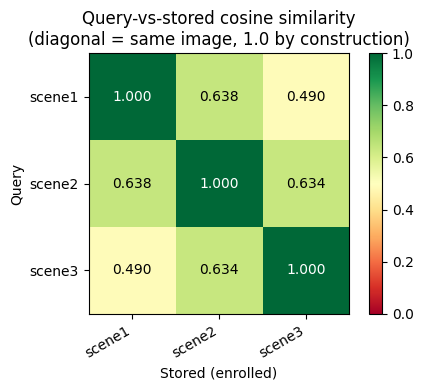

In [ ]:
# Visualise similarities as a heatmap
n = len(names)
sim_matrix = np.zeros((n, n))
for i, query_name in enumerate(names):
    q_emb = embed_face(person_crops[query_name])
    for j, stored_name in enumerate(names):
        results = face_collection.query(
            query_embeddings=[q_emb.tolist()],
            n_results=1,
            where={'name': stored_name},
            include=['distances']
        )
        sim_matrix[i, j] = 1 - results['distances'][0][0]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix, vmin=0, vmax=1, cmap='RdYlGn')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_yticklabels(names)
ax.set_xlabel('Stored (enrolled)')
ax.set_ylabel('Query')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim_matrix[i,j]:.3f}', ha='center', va='center', fontsize=10,
                color='white' if sim_matrix[i,j] < 0.4 or sim_matrix[i,j] > 0.85 else 'black')
ax.set_title('Query-vs-stored cosine similarity\n(diagonal = same image, 1.0 by construction)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## From Notebook to Application

Each step above becomes a module of the terminal application in [`../4-face-auth-app/`](../4-face-auth-app/):

| Step | This notebook | App module |
|------|--------------|----------------|
| Capture | static images (or `capture_faces_from_webcam()`) | `face_auth.py` reads `IMAGE_PATH` from `.env` |
| Quality check | brightness and Laplacian checks inside `capture_faces_from_webcam()` | `quality_guard.py` -> `check_image_quality()` |
| Detect + crop | `detect_and_crop_person()` using `yolo26n.pt` | `quality_guard.py` -> `detect_and_crop_person()` |
| Embed | `embed_face()` using `clip-ViT-B-32` | `verification.py` -> `embed_face()` |
| Store | `face_collection.add()` | `enroll.py` |
| Verify | `face_collection.query()` + threshold | `verification.py` -> `verify_identity()` |

Turning the notebook into an application changes more than the file layout:

- **Configuration** moves from hard-coded values to a `.env` file read with Pydantic Settings.
- **Every failure becomes a decision.** When no person is detected, this notebook falls back to the whole image, which is fine for a demo. In an access-control system that fallback would be a security hole, so the app denies access instead.
- **Models load once** and are reused, instead of living in global notebook variables.

The app's README lists what is still missing before this could be trusted with a real door.

## Cleanup

In [ ]:
import shutil

# Remove the demo database
shutil.rmtree('../artifacts/face_db', ignore_errors=True)
print('Cleanup done')

Cleanup done


Next: [4-face-auth-app](../4-face-auth-app/) turns this notebook into a terminal application, and measures honestly how well it works.